In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
import math
import shelve
import string
import numba as nb
import timeit
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib import colors
import shelve
import uuid

In [2]:
with shelve.open('data/data_sets.shelve', 'r') as shelf:
    data = shelf['lorenz'] 
    
data_scaled = data
data_sampled= data_scaled [:,::20]

ut0 = data_scaled[:,::20]
utmid = data_scaled[:,10:][:,::20]
ut1 = data_scaled[:,20:][:,::20]

In [3]:
def f(z, u, omega,K,F,pvec):
    M  = len(z)
    df = np.zeros(M,dtype = 'complex_')
    for j in range(M):
        zdum =0 
        for i in range(M):
            zdum+= np.conjugate(z[i])*z[j]**2 - z[i] 
        df[j]  =  (F/2)*(np.exp(1j*u[pvec[j]]) - np.exp(-1*1j*u[pvec[j]])*z[j]**2) + (1j*omega[j]-1)*z[j]  -\
        K*(zdum)/(2*M)
    return df

def frk4_step(z,u0,umid,u1,h,w,K,F,pvec):
    k1 = h * f( z, u0,w,K,F,pvec)
    k2 = h * f(z + 0.5 * k1, umid,w,K,F,pvec)
    k3 = h * f( z + 0.5 * k2, umid,w,K,F,pvec)
    k4 = h * f(z + k3, u1, w,K,F,pvec)
    znew = z + (1.0 / 6.0)*(k1 + 2 * k2 + 2 * k3 + k4)
    return znew

def whipeout(initlen, ut0,utmid,ut1, x0, h,w,p,pvec):
    uin, K,F= p[0],p[1], p[2]  
    for j in nb.prange(initlen):
        U0 = ut0[:,j]
        Umid = utmid[:,j]
        U1 = ut1[:,j]
        x  = frk4_step(x0,uin*U0,uin*Umid,uin*U1,h,w,K,F,pvec)
        x0 = x
    return x

def kura_run(M,runlen, ut0, utmid,ut1, x0, h,w,p,pvec):
    uin, K,F = p[0],p[1], p[2]
    X = np.empty((M,runlen),'complex_')
    for j in nb.prange(runlen):
        U0 = ut0[:,j]
        Umid = utmid[:,j]
        U1 = ut1[:,j]
        x  = frk4_step(x0,uin*U0,uin*Umid,uin*U1,h,w,K,F,pvec)
        x0 = x
        X[:,j] = x
    return X

@nb.njit() 
def numba_norm(a):
    n = a.shape[0]
    norm = 0
    for i in range(n):
        norm += a[i] * a[i]
    return np.sqrt(norm)

@nb.njit()
def NMSE(yeval,ydata):
    nmse = np.zeros(yeval.shape[0], dtype='float64')
    for i in nb.prange(yeval.shape[0]):
        for j in nb.prange(yeval.shape[1]):
            nmse[i] += (ydata[i,j]-yeval[i,j])**2
        nmse[i]=nmse[i]/numba_norm(ydata[i,:])**2
    return nmse


def test_closed(z0,p,Wout,w,h,M,N,s_steps,pvec):
    Ztest=np.zeros((M,s_steps), dtype='complex_')
    Upred=np.zeros((N,s_steps), dtype='float64')
    z=z0
    for i in nb.prange(s_steps):
        #print(z)
        z = frk4closed_step(z,p,Wout,w,h,M,pvec)
        Ztest[:,i] = z
        x=np.angle(z)
        Upred[:,i]= Wout @ np.hstack([1, np.sin(x), np.sin(x)**2])
    return Ztest, Upred

def frk4closed_step(y,p,Wout,w,h,M,pvec):
    k1 = h * fkura_closed( y,p,Wout,w,M,pvec)
    k2 = h * fkura_closed(y + 0.5 * k1, p,Wout,w,M,pvec)
    k3 = h * fkura_closed( y + 0.5 * k2, p,Wout,w,M,pvec)
    k4 = h * fkura_closed(y + k3, p,Wout,w,M,pvec)
    y = y + (1.0 / 6.0)*(k1 + 2 * k2 + 2 * k3 + k4)
    return y

def fkura_closed(z,p,Wout,omega,M,pvec):  
    uin, K,F = p[0],p[1],p[2]
    df = np.zeros(M,dtype='complex_')
    x = np.angle(z)
    
    Up0= Wout @ np.hstack([1, np.sin(x), np.sin(x)**2])
    for j in range(M):
        zdum =0 
        for i in range(M):
            zdum+= np.conjugate(z[i])*z[j]**2 - z[i] 
        df[j]  =  (F/2)*(np.exp(1j*Up0[pvec[j]]*uin) - np.exp(-1*1j*Up0[pvec[j]]*uin)*z[j]**2) \
        + (1j*omega[j]-1)*z[j] - K*(zdum)/(2*M)
    return df

In [4]:
def fVec(X,Wout,omega,p, pvec, M,N):
    uin, K,F = p[0],p[1],p[2]     

    x = np.zeros(M)
    y = np.zeros(M)

    for i in range(M):
        x[i] = X[i*2]
        y[i] = X[1+2*i]

    
    utest = np.zeros(M)

    Psiv = np.zeros(M)
    for j in range(M):
        Psiv[j] = np.arctan(y[j]/x[j])

    utest0 = np.zeros(N)
    utest0+= Wout[:,0]
    utest0+= Wout[:,1:M+1]@ np.sin(Psiv)
    utest0+= Wout[:,M+1:2*M+1]@ (np.sin(Psiv)**2)


    utest = np.zeros(M)
    for j in range(M):
        utest[j] = utest0[pvec[j]]*uin

    Y = np.zeros(2*M)
    for j in range(M):
        xdum = 0
        for i in range(M):
            xdum += x[i]*x[j]**2 + 2*y[i]*y[j]*x[j] - x[i]*y[j]**2 -x[i]
        Y[j*2] = -F*(2*x[j]*y[j]*np.sin(utest[j]) + (x[j]**2 - y[j]**2)*np.cos(utest[j]) - np.cos(utest[j]))/2 - x[j] - omega[j]*y[j]    - \
        (K/(2*M))*( xdum )
        ydum = 0
        for i in range(M):
            ydum += 2*x[i]*x[j]*y[j]-y[i]*x[j]**2+y[i]*y[j]**2-y[i] 
        Y[1+j*2] = F*(-2*x[j]*y[j]*np.cos(utest[j]) + (x[j]**2 - y[j]**2)*np.sin(utest[j]) + np.sin(utest[j]))/2  + omega[j]*x[j]-y[j] - \
        (K/(2*M))*( ydum )

    return Y


def X2u(X,Wout,M,N):
    x = np.zeros(M)
    y = np.zeros(M)
    for i in range(M):
        x[i] = X[i*2]
        y[i] = X[1+2*i]
    Psiv = np.zeros(M)
    for j in range(M):
        Psiv[j] = np.arctan(y[j]/x[j])

    utest = np.zeros(N)
    utest+= Wout[:,0]
    utest+= Wout[:,1:M+1]@ np.sin(Psiv)
    utest+= Wout[:,M+1:2*M+1]@ (np.sin(Psiv)**2)

    return utest

def jaci(X,Wout,omega,p,pvec,M,N):
    uin, K,F = p[0],p[1],p[2]
    x = np.zeros(M)
    y = np.zeros(M)
    
    for i in range(M):
        x[i] = X[i*2]
        y[i] = X[1+2*i]

    Psiv = np.zeros(M)
    for j in range(M):
        Psiv[j] = np.arctan(y[j]/x[j])
        
    utest0 = np.zeros(N)
    utest0+= Wout[:,0]
    utest0+= Wout[:,1:M+1]@ np.sin(Psiv)
    utest0+= Wout[:,M+1:2*M+1]@ (np.sin(Psiv)**2)

    utest = np.zeros(M)
    for j in range(M):
        utest[j] = utest0[pvec[j]]*uin
        
    
    Dutest = uin*Du_full(X,Wout,pvec,M,N)
    
    J = np.zeros((2*M,2*M))

    for j in range(M):
        for i in range(2*M):
            if 2*j == i:
                xjdum = 3*x[j]**2 + y[j]**2 -1
                for k in range(M):
                    if k != j:
                        xjdum +=2*x[k]*x[j] + 2*y[k]*y[j]

                J[2*j,i] = -F*(2*x[j]*y[j]*np.cos(utest[j])*Dutest[j,i] + 2*x[j]*np.cos(utest[j]) + 2.0*y[j]*np.sin(utest[j]) - \
                               (x[j]**2 - y[j]**2)*np.sin(utest[j])*Dutest[j,i] + np.sin(1.0*utest[j])*Dutest[j,i])/2  - 1  - (K/(2*M))*xjdum
                
                yjdum =  2 * x[j]*y[j]-1*y[j]*x[j]
                for k in range(M):
                    if k != j:
                        yjdum += x[k]*y[j]-y[k]*x[j]

                J[2*j+1,i] = F*(2.0*x[j]*y[j]*np.sin(utest[j])*Dutest[j,i] + 2.0*x[j]*np.sin(utest[j]) - 2.0*y[j]*np.cos(utest[j]) +  \
                                (x[j]**2 - y[j]**2)*np.cos(utest[j])*Dutest[j,i] + np.cos(utest[j])*Dutest[j,i])/2  + omega[j] - (K/(M))*(yjdum)
            elif (2*j +1)== i:
                #j=1 , i =1
                xjdum = y[j]*x[j]
                for k in range(M):
                    if k!= j:
                        xjdum += y[k]*x[j]- x[k]*y[j] 

                J[2*j,i] = -F*(2.0*x[j]*y[j]*np.cos(utest[j])*Dutest[j,i] + 2.0*x[j]*np.sin(utest[j]) - 2.0*y[j]*np.cos(utest[j]) - \
                               (x[j]**2 - 1.0*y[j]**2)*np.sin(utest[j])*Dutest[j,i] + 1.0*np.sin(1.0*utest[j])*Dutest[j,i])/2 - 1.0*omega[j] -(K/(M))*xjdum

                yjdum = x[j]**2 +3*y[j]**2 -1 
                for k in range(M):
                    if k != j:
                        yjdum += 2*x[k]*x[j]+2*y[k]*y[j]
    
                J[2*j+1,i] = F*(2.0*x[j]*y[j]*np.sin(utest[j])*Dutest[j,i] - 2.0*x[j]*np.cos(utest[j]) - 2.0*y[j]*np.sin(utest[j]) + \
                              1.0*(x[j]**2 - y[j]**2)*np.cos(utest[j])*Dutest[j,i] + 1.0*np.cos(1.0*utest[j])*Dutest[j,i])/2  - 1.0 - (K/(2*M))*yjdum

            elif ((i) % 2) ==0:
             
                J[2*j,i]= -F*(2.0*x[j]*y[j]*np.cos(utest[j]) - (x[j]**2 - 1.0*y[j]**2)*np.sin(utest[j]) + 1.0*np.sin(1.0*utest[j]))*Dutest[j,i]/2 + K*(-x[j]**2 + 1.0*y[j]**2 + 1)/(2*M)               
                J[2*j+1,i] =  F*(2.0*x[j]*y[j]*np.sin(utest[j]) + 1.0*(x[j]**2 - y[j]**2)*np.cos(utest[j]) + 1.0*np.cos(1.0*utest[j]))*Dutest[j,i]/2  -  K*x[j]*y[j]/M


            elif ((i) % 2) ==1:

                J[2*j,i]=  -F*(2.0*x[j]*y[j]*np.cos(utest[j]) - (x[j]**2 - 1.0*y[j]**2)*np.sin(utest[j]) + 1.0*np.sin(1.0*utest[j]))*Dutest[j,i]/2 - \
                K*x[j]*y[j]/M
                
                J[2*j+1,i] = F*(2.0*x[j]*y[j]*np.sin(utest[j]) + 1.0*(x[j]**2 - y[j]**2)*np.cos(utest[j]) + 1.0*np.cos(1.0*utest[j]))*Dutest[j,i]/2 + \
                K*(x[j]**2 - y[j]**2 + 1)/(2*M)
                
    return J

def sinpsi_x(x,y):
    return -y*np.abs(x)/(x**2 + y**2)**(3/2)
def sinpsi_y(x,y):
    return x*np.abs(x)/(x**2 + y**2)**(3/2)
def sin2psi_x(x,y):
    return -2*x*y**2/(x**2 + y**2)**2
def sin2psi_y(x,y):
    return 2*x**2*y/(x**4 + 2*x**2*y**2 + y**4)

def Du_full(X,Wtest, pvec, M,N):
    Dudum = np.zeros((N,2*M))
    Dutest = np.zeros((M,2*M))
    x = np.zeros(M)
    y = np.zeros(M)
    
    for i in range(M):
        x[i] = X[i*2]
        y[i] = X[1+2*i]

    
    W1 = Wtest[:,1:M+1]
    W2 = Wtest[:,M+1:2*M+1]


    for i in range(N):
        for j in range(M):
            Dudum[i,j*2]+= W1[i,j]*sinpsi_x(x[j],y[j])+ W2[i,j]*sin2psi_x(x[j],y[j])
            Dudum[i,j*2+1]+= W1[i,j]*sinpsi_y(x[j],y[j])+ W2[i,j]*sin2psi_y(x[j],y[j])
    
    for i in range(M):
        Dutest[i,:] = Dudum[pvec[i],:]
    return Dutest




def assemble(v, U, M,k):
    new_state = np.empty(M*2+2*M*k, dtype='float64')
    new_state[:M*2] = v 
    new_state[M*2:] = U.flatten()
    return new_state

def disassemble(state, M,k):
    new_v = state[:M*2] 
    new_U = state[M*2:].reshape(2*M, k)
    return new_v, new_U

def dSdt( f,fjac,Wout, omega, p, pvec, state, M,N,k):
    v, U = disassemble(state, M,k)
    dv = f(v, Wout, omega,p,pvec,M,N)
    dU = fjac(v, Wout, omega,p,pvec,M,N) @ U
    return assemble(dv, dU, M,k)

def varRK4(f, fjac,state, dt, Wout, omega,p,pvec,M,N,k):
    k1 = dt*dSdt( f, fjac, Wout, omega, p, pvec, state, M, N,k)
    k2 = dt*dSdt(f,fjac,Wout, omega, p, pvec, state + 0.5 * k1, M,N,k)
    k3 = dt*dSdt(f, fjac,Wout, omega, p, pvec, state + 0.5 * k2, M, N,k)
    k4 = dt*dSdt(f, fjac,Wout, omega, p, pvec,state +  k3, M, N,k)
    return state + (1/6) * (k1 + 2*k2 + 2*k3 + k4)

@nb.njit()
def gram_schmidt(U,k):
    N = np.shape(U)[0]
    W = U.copy().astype(np.float64)
    V = np.empty((N, k),dtype='float64')
    norms = np.empty(k,dtype='float64')
    for i in range(k):
        for j in range(i):
            W[:, i] = W[:, i] - numba_dot2(U[:, i], V[:, j]) * V[:, j]
        norms[i] = numba_norm(W[:, i])
        V[:, i] = W[:, i] / norms[i]
    return V, norms 

@nb.njit()
def numba_dot2(a, b):
    n = a.shape[0]
    dot = 0
    for i in range(n):
        dot += a[i] * b[i]
    return dot

@nb.njit() 
def numba_norm(a):
    n = a.shape[0]
    norm = 0
    for i in range(n):
        norm += a[i] * a[i]
    return np.sqrt(norm)

def solve_lya(x0, Wout,omega,p, pvec, M, N,m, dt,k=1):
    
    LEi_sort = []
    trJi_sort = []

    LE = np.zeros(k)  # Lyapunov exponents
    e = np.eye(2*M, k)  # make a matrix of variations (N x k)

    U_pred = np.zeros((3,m-1))
    traceJ = np.zeros(m)
    X=np.zeros((M*2,m))
    X[:,0] = x0
    
    LEi_sort = np.zeros((k,m-1))
    trJi_sort = np.zeros( (m-1) )
    k0=0 # indexing for first lya_dummy to compute mean and std
    trJ = 0  # integral of the trace of Jacobian matrix
    oldtraceJ =  np.trace(jaci(x0,Wout,omega,p,pvec,M,N)) # trace of Jacobian matrix in previous step   
    for i in range(0,m-1):
        state= assemble(X[:,i], e, M,k)        
        X[:,i+1], e = disassemble(varRK4(fVec, jaci, state, dt, Wout,omega,p,pvec,M,N,k),M,k)
        #print(e.shape)
        e, nrm = gram_schmidt(e,k)
        LE = LE + np.log(nrm)
        
        Up = X2u(X[:,i+1],Wout,M,N)
        U_pred[:,i]= Up  
        
        traceJ = np.trace(jaci(X[:,i+1],Wout,omega,p,pvec,M,N))
        trJ = trJ + 0.5 * dt * (oldtraceJ + traceJ)  # sum of LEs
        oldtraceJ = traceJ

        LEi_sort[:,i]= LE / (dt*(i+1))
        trJi_sort[i]= trJ / (dt*(i+1))
   
    return LEi_sort,trJi_sort , U_pred

In [55]:
    initlen=5_000
    trainlen=20_000
    testlen=30_000

    M=6
    N=3
    pvec=[0,1,2,0,1,2]

    p= np.array([1e-02, 8.0e+01, 5.5e+01])
    reg=1e-11
    omega0 = np.array([-0.14, -0.11,  0.4 , -0.34, -0.18, -0.03])
    h=0.01


    Ytest = data_scaled[:,::20][:,(initlen+trainlen+1):(initlen+trainlen+1+testlen)]

    h=0.01
    
    z0 = np.ones(M)
    while np.any(np.abs(z0)>1): 
        z0 = (np.random.rand(M)*1j + np.random.rand(M))


    znew = whipeout(initlen, ut0,utmid,ut1, z0, h,omega0,p,pvec)
    Ztrain = kura_run(M,trainlen, ut0[:,initlen:], utmid[:,initlen:],ut1[:,initlen:], znew, h,omega0,p,pvec)
    Xtrain = np.angle(Ztrain)
    X =  np.concatenate((np.expand_dims(np.ones(Xtrain.shape[1]),axis=0),np.sin(Xtrain),np.sin(Xtrain)**2),axis=0)

    Yt = data_scaled[:,::20][:,(initlen+1):(initlen+trainlen+1)].T

    Wout = np.linalg.solve( np.dot(X,X.T) + reg*np.eye(2*len(z0)+1) , np.dot(X,Yt) ).T

    pred = (Wout @ X)
    nmse_train = NMSE(  pred, Yt.T).mean()
    print(nmse_train)
    testlen=30_000
    z0 = Ztrain[:,-1]
    Ztest, Upred = test_closed(z0,p,Wout,omega0,h,M,N,testlen,pvec)
    nmse_test= NMSE(Upred[:,:500],Ytest[:,:500])
    print(np.linalg.norm(nmse_test,2))




    if np.mean(nmse_test) <2:
        print('yes')

        x0 = np.real(z0)
        y0 = np.imag(z0)
        X_Y = np.zeros(M*2)
        for i in range(M):
            X_Y[2*i] = x0[i]
            X_Y[2*i+1] = y0[i]
        LE,trJ , Upred =  solve_lya(X_Y, Wout,omega0,p,pvec, M, N, 60_000, h,k=4)
        LE_shelf = LE[:,5000:]


1.983850262922753e-06
1.0057393729861133
yes


In [68]:
LE.shape

(4, 59999)

In [69]:
LE_check = np.zeros((3,400))
i=0
for k in range(40_000,0,-100):
    LE_check[:,i] = LE[:3,-20_000-k:-k-1].mean(axis=1)
    i += 1

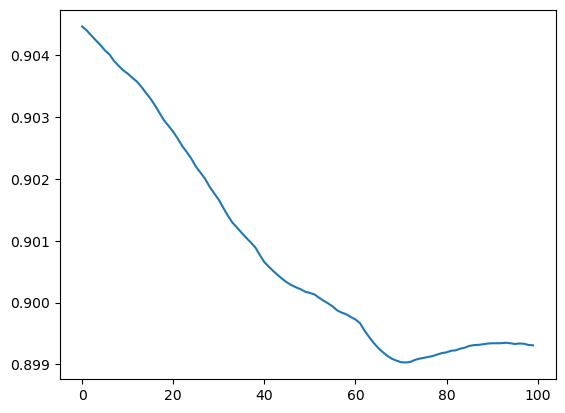

In [70]:
plt.plot(LE_check[0,-100:].T)

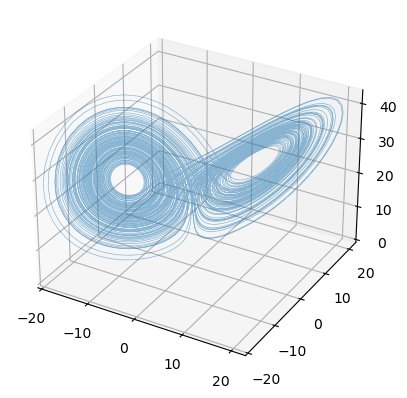

In [80]:
    ax = plt.figure().add_subplot(projection='3d')
    ax.plot(*Upred[:,2000:12_000], lw=0.5,alpha=0.5)
    #ax.plot(*Ytest,color='green',lw=0.5,alpha=0.5)
    ax.set_zlim(0, 43)
    ax.set_xlim(-20, 22)
    ax.set_ylim(-20, 22)

    ax.xaxis.set_ticklabels([])
    ax.yaxis.set_ticklabels([])
    ax.zaxis.set_ticklabels([])
    plt.savefig(f'shelve/pictures_paper/6d/upred6d_paper.jpg',dpi=300,bbox_inches = 'tight')

In [19]:
LE[:3,-10_000:].mean(axis=1)

array([  0.8623086 ,   0.02178063, -15.43669775])

(-1.0, 1.0)

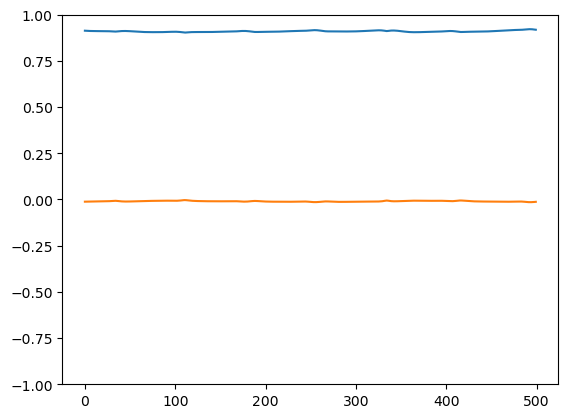

In [11]:
plt.plot(LE[:,-500:].T)
plt.ylim(-1,1)


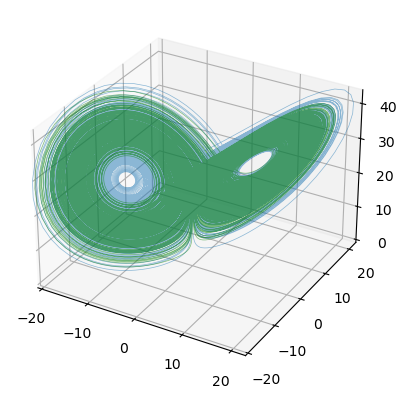

In [64]:
    ax = plt.figure().add_subplot(projection='3d')
    ax.plot(*Upred[:,:], lw=0.5,alpha=0.5)
    ax.plot(*Ytest,color='green',lw=0.5,alpha=0.5)
    ax.set_zlim(0, 43)
    ax.set_xlim(-20, 22)
    ax.set_ylim(-20, 22)
    ax.xaxis.set_ticks(np.arange(-20, 21, 10))
    ax.yaxis.set_ticks(np.arange(-20, 21, 10))
    ax.zaxis.set_ticks(np.arange(0, 41, 10))

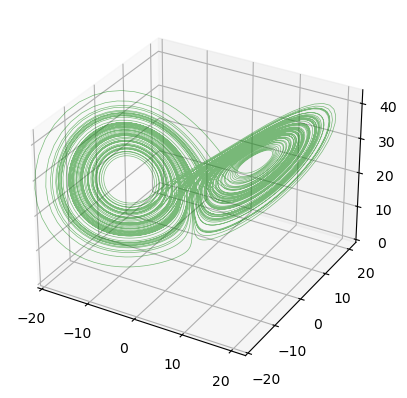

In [15]:
    ax = plt.figure().add_subplot(projection='3d')
    ax.plot(*Ytest,color='green',lw=0.5,alpha=0.5)
    ax.set_zlim(0, 43)
    ax.set_xlim(-20, 22)
    ax.set_ylim(-20, 22)
    ax.xaxis.set_ticks(np.arange(-20, 21, 10))
    ax.yaxis.set_ticks(np.arange(-20, 21, 10))
    ax.zaxis.set_ticks(np.arange(0, 41, 10))
    plt.savefig(f'shelve/pictures_paper/ytest.jpg',dpi=300,bbox_inches = 'tight')


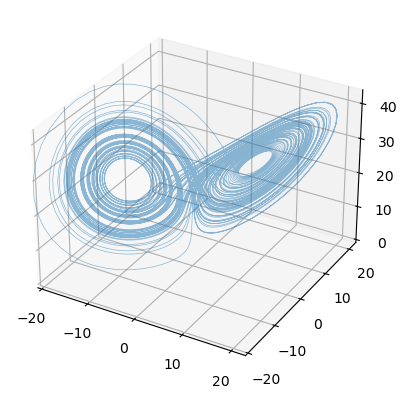

In [16]:
    ax = plt.figure().add_subplot(projection='3d')
    ax.plot(*Upred[:,:], lw=0.5,alpha=0.5)
    ax.set_zlim(0, 43)
    ax.set_xlim(-20, 22)
    ax.set_ylim(-20, 22)
    ax.xaxis.set_ticks(np.arange(-20, 21, 10))
    ax.yaxis.set_ticks(np.arange(-20, 21, 10))
    ax.zaxis.set_ticks(np.arange(0, 41, 10))
    plt.savefig(f'shelve/pictures_paper/6d/upred6d_{np.round(LE[:3,-500:].mean(axis=1),3)}.jpg',dpi=300,bbox_inches = 'tight')